In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:

# import pandas as pd

# data= pd.read_csv("BATCHY_LASSO_VAL.csv")

# data = data.T

# # Labels from row index
# y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
# y = y.drop("Gene")
# y = y.values.astype(int)

# # Feature matrix
# data = data.reset_index(drop=True)
# data.columns = data.iloc[0]
# data = data.drop(data.index[0]).apply(pd.to_numeric)
# X = data
# y_val = y
# X_val = X
# import pickle
# import joblib
# best_model = joblib.load('/content/lightgbm_best_model.pkl')

# # Open the file in read-binary mode



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/L_GBM/10_10"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 5, 10, 20],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

cv_df['mean_train_score'] *= 100
cv_df['std_train_score'] *= 100
cv_df['mean_test_score'] *= 100
cv_df['std_test_score'] *= 100

# ── Save best model ───────────────────────────────────────────────
model_path = os.path.join(save_dir, "lightgbm_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── Save best parameters ──────────────────────────────────────────
results_dict = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy": round(test_score * 100, 4),
    "std_deviation": round(std_score * 100, 4)
}

json_path = os.path.join(save_dir, "best_params_scores.json")

with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"[Saved] Params+Scores      → {json_path}")

# ── Save full CV results JSON ─────────────────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}

cv_json_path = os.path.join(save_dir, "cv_results_grid.json")

with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)

print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── Save full CV CSV ──────────────────────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)

print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── Save confusion matrix ─────────────────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")

with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))

print(f"[Saved] Confusion Matrix   → {cm_path}")

# ── Save classification report ────────────────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))

print(f"[Saved] Classification Rep → {report_path}")

# ── Parameter summaries ───────────────────────────────────────────
score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]

params = list(param_grid.keys())

for param in params:

    col = f'param_{param}'

    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )

    param_summary.insert(
        1,
        'count',
        cv_df.groupby(col).size().values
    )

    param_path = os.path.join(
        save_dir,
        f"param_{param}.csv"
    )

    param_summary.to_csv(param_path, index=False)

    print(f"[Saved] param_{param:<20} → {param_path}")

# ── Ranked configurations ─────────────────────────────────────────
param_cols = [f'param_{p}' for p in params]

score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

summary_cols = (
    ['rank_test_score']
    + param_cols
    + score_cols
)

summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

summary_df = summary_df[summary_cols]

summary_df = (
    summary_df
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

summary_path = os.path.join(
    save_dir,
    "cv_results_ranked.csv"
)

summary_df.to_csv(summary_path, index=False)

print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(
    save_dir,
    "top10_configs.csv"
)

summary_df.head(10).to_csv(top10_path, index=False)

print(f"[Saved] Top 10 Configs     → {top10_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/L_GBM/10_5"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':       [100, 200, 300, 400, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 5, 10, 20],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

cv_df['mean_train_score'] *= 100
cv_df['std_train_score'] *= 100
cv_df['mean_test_score'] *= 100
cv_df['std_test_score'] *= 100

# ── Save best model ───────────────────────────────────────────────
model_path = os.path.join(save_dir, "lightgbm_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── Save best parameters ──────────────────────────────────────────
results_dict = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy": round(test_score * 100, 4),
    "std_deviation": round(std_score * 100, 4)
}

json_path = os.path.join(save_dir, "best_params_scores.json")

with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"[Saved] Params+Scores      → {json_path}")

# ── Save full CV results JSON ─────────────────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}

cv_json_path = os.path.join(save_dir, "cv_results_grid.json")

with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)

print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── Save full CV CSV ──────────────────────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)

print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── Save confusion matrix ─────────────────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")

with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))

print(f"[Saved] Confusion Matrix   → {cm_path}")

# ── Save classification report ────────────────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))

print(f"[Saved] Classification Rep → {report_path}")

# ── Parameter summaries ───────────────────────────────────────────
score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]

params = list(param_grid.keys())

for param in params:

    col = f'param_{param}'

    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )

    param_summary.insert(
        1,
        'count',
        cv_df.groupby(col).size().values
    )

    param_path = os.path.join(
        save_dir,
        f"param_{param}.csv"
    )

    param_summary.to_csv(param_path, index=False)

    print(f"[Saved] param_{param:<20} → {param_path}")

# ── Ranked configurations ─────────────────────────────────────────
param_cols = [f'param_{p}' for p in params]

score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

summary_cols = (
    ['rank_test_score']
    + param_cols
    + score_cols
)

summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

summary_df = summary_df[summary_cols]

summary_df = (
    summary_df
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

summary_path = os.path.join(
    save_dir,
    "cv_results_ranked.csv"
)

summary_df.to_csv(summary_path, index=False)

print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(
    save_dir,
    "top10_configs.csv"
)

summary_df.head(10).to_csv(top10_path, index=False)

print(f"[Saved] Top 10 Configs     → {top10_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 50 folds for each of 576 candidates, totalling 28800 fits
Best Parameters     : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}
Best CV Accuracy    : 99.71%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 99.71%
Std Deviation       : 2.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/L_GBM/10_5/lightgbm_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/L_GBM/10_5/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/L_GBM/10_5/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/L_GBM/10_5/

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/L_GBM/10_2"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':       [100, 200, 300, 400, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 5, 10, 20],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

cv_df['mean_train_score'] *= 100
cv_df['std_train_score'] *= 100
cv_df['mean_test_score'] *= 100
cv_df['std_test_score'] *= 100

# ── Save best model ───────────────────────────────────────────────
model_path = os.path.join(save_dir, "lightgbm_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── Save best parameters ──────────────────────────────────────────
results_dict = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy": round(test_score * 100, 4),
    "std_deviation": round(std_score * 100, 4)
}

json_path = os.path.join(save_dir, "best_params_scores.json")

with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"[Saved] Params+Scores      → {json_path}")

# ── Save full CV results JSON ─────────────────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}

cv_json_path = os.path.join(save_dir, "cv_results_grid.json")

with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)

print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── Save full CV CSV ──────────────────────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)

print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── Save confusion matrix ─────────────────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")

with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))

print(f"[Saved] Confusion Matrix   → {cm_path}")

# ── Save classification report ────────────────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))

print(f"[Saved] Classification Rep → {report_path}")

# ── Parameter summaries ───────────────────────────────────────────
score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]

params = list(param_grid.keys())

for param in params:

    col = f'param_{param}'

    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )

    param_summary.insert(
        1,
        'count',
        cv_df.groupby(col).size().values
    )

    param_path = os.path.join(
        save_dir,
        f"param_{param}.csv"
    )

    param_summary.to_csv(param_path, index=False)

    print(f"[Saved] param_{param:<20} → {param_path}")

# ── Ranked configurations ─────────────────────────────────────────
param_cols = [f'param_{p}' for p in params]

score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

summary_cols = (
    ['rank_test_score']
    + param_cols
    + score_cols
)

summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

summary_df = summary_df[summary_cols]

summary_df = (
    summary_df
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

summary_path = os.path.join(
    save_dir,
    "cv_results_ranked.csv"
)

summary_df.to_csv(summary_path, index=False)

print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(
    save_dir,
    "top10_configs.csv"
)

summary_df.head(10).to_csv(top10_path, index=False)

print(f"[Saved] Top 10 Configs     → {top10_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 20 folds for each of 576 candidates, totalling 11520 fits
Best Parameters     : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 15, 'subsample': 0.8}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/L_GBM/10_2/lightgbm_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/L_GBM/10_2/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/L_GBM/10_2/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/L_GBM/10_

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/L_GBM/10only"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':       [100, 200, 300, 400, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 5, 10, 20],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

# ── Stratified K-Fold ─────────────────────────────────────────────
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

cv_df['mean_train_score'] *= 100
cv_df['std_train_score'] *= 100
cv_df['mean_test_score'] *= 100
cv_df['std_test_score'] *= 100

# ── Save best model ───────────────────────────────────────────────
model_path = os.path.join(save_dir, "lightgbm_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── Save best parameters ──────────────────────────────────────────
results_dict = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy": round(test_score * 100, 4),
    "std_deviation": round(std_score * 100, 4)
}

json_path = os.path.join(save_dir, "best_params_scores.json")

with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"[Saved] Params+Scores      → {json_path}")

# ── Save full CV results JSON ─────────────────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}

cv_json_path = os.path.join(save_dir, "cv_results_grid.json")

with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)

print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── Save full CV CSV ──────────────────────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)

print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── Save confusion matrix ─────────────────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")

with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))

print(f"[Saved] Confusion Matrix   → {cm_path}")

# ── Save classification report ────────────────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))

print(f"[Saved] Classification Rep → {report_path}")

# ── Parameter summaries ───────────────────────────────────────────
score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]

params = list(param_grid.keys())

for param in params:

    col = f'param_{param}'

    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )

    param_summary.insert(
        1,
        'count',
        cv_df.groupby(col).size().values
    )

    param_path = os.path.join(
        save_dir,
        f"param_{param}.csv"
    )

    param_summary.to_csv(param_path, index=False)

    print(f"[Saved] param_{param:<20} → {param_path}")

# ── Ranked configurations ─────────────────────────────────────────
param_cols = [f'param_{p}' for p in params]

score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

summary_cols = (
    ['rank_test_score']
    + param_cols
    + score_cols
)

summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

summary_df = summary_df[summary_cols]

summary_df = (
    summary_df
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

summary_path = os.path.join(
    save_dir,
    "cv_results_ranked.csv"
)

summary_df.to_csv(summary_path, index=False)

print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(
    save_dir,
    "top10_configs.csv"
)

summary_df.head(10).to_csv(top10_path, index=False)

print(f"[Saved] Top 10 Configs     → {top10_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 10 folds for each of 576 candidates, totalling 5760 fits
Best Parameters     : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 15, 'subsample': 0.8}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/L_GBM/10only/lightgbm_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/L_GBM/10only/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/L_GBM/10only/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/L_GB

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import json
import numpy as np
import pandas as pd
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/L_GBM/5only"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'n_estimators':       [100, 200, 300, 400, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [-1, 5, 10, 20],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

# ── Stratified K-Fold ─────────────────────────────────────────────
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── Build master DataFrame ────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

cv_df['mean_train_score'] *= 100
cv_df['std_train_score'] *= 100
cv_df['mean_test_score'] *= 100
cv_df['std_test_score'] *= 100

# ── Save best model ───────────────────────────────────────────────
model_path = os.path.join(save_dir, "lightgbm_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model              → {model_path}")

# ── Save best parameters ──────────────────────────────────────────
results_dict = {
    "best_params": grid_search.best_params_,
    "best_cv_accuracy": round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy": round(test_score * 100, 4),
    "std_deviation": round(std_score * 100, 4)
}

json_path = os.path.join(save_dir, "best_params_scores.json")

with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)

print(f"[Saved] Params+Scores      → {json_path}")

# ── Save full CV results JSON ─────────────────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}

cv_json_path = os.path.join(save_dir, "cv_results_grid.json")

with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)

print(f"[Saved] CV Grid JSON       → {cv_json_path}")

# ── Save full CV CSV ──────────────────────────────────────────────
full_csv_path = os.path.join(save_dir, "cv_results_full.csv")
cv_df.to_csv(full_csv_path, index=False)

print(f"[Saved] CV Grid CSV        → {full_csv_path}")

# ── Save confusion matrix ─────────────────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")

with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))

print(f"[Saved] Confusion Matrix   → {cm_path}")

# ── Save classification report ────────────────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")

with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))

print(f"[Saved] Classification Rep → {report_path}")

# ── Parameter summaries ───────────────────────────────────────────
score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]

params = list(param_grid.keys())

for param in params:

    col = f'param_{param}'

    param_summary = (
        cv_df
        .groupby(col)[score_cols]
        .mean()
        .reset_index()
        .sort_values('mean_test_score', ascending=False)
        .rename(columns={col: param})
    )

    param_summary.insert(
        1,
        'count',
        cv_df.groupby(col).size().values
    )

    param_path = os.path.join(
        save_dir,
        f"param_{param}.csv"
    )

    param_summary.to_csv(param_path, index=False)

    print(f"[Saved] param_{param:<20} → {param_path}")

# ── Ranked configurations ─────────────────────────────────────────
param_cols = [f'param_{p}' for p in params]

score_cols = [
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'mean_fit_time'
]

summary_cols = (
    ['rank_test_score']
    + param_cols
    + score_cols
)

summary_df = cv_df.loc[:, ~cv_df.columns.duplicated()].copy()

summary_df = summary_df[summary_cols]

summary_df = (
    summary_df
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

summary_path = os.path.join(
    save_dir,
    "cv_results_ranked.csv"
)

summary_df.to_csv(summary_path, index=False)

print(f"[Saved] Ranked Summary     → {summary_path}")

top10_path = os.path.join(
    save_dir,
    "top10_configs.csv"
)

summary_df.head(10).to_csv(top10_path, index=False)

print(f"[Saved] Top 10 Configs     → {top10_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Parameters     : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model              → /content/drive/MyDrive/L_GBM/5only/lightgbm_best_model.pkl
[Saved] Params+Scores      → /content/drive/MyDrive/L_GBM/5only/best_params_scores.json
[Saved] CV Grid JSON       → /content/drive/MyDrive/L_GBM/5only/cv_results_grid.json
[Saved] CV Grid CSV        → /content/drive/MyDrive/L_GBM/5o

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.model_selection import GridSearchCV


In [ ]:
import pickle
best_model = joblib.load('/content/drive/MyDrive/L_GBM/10_2/lightgbm_best_model.pkl')

# Open the file in read-binary mode



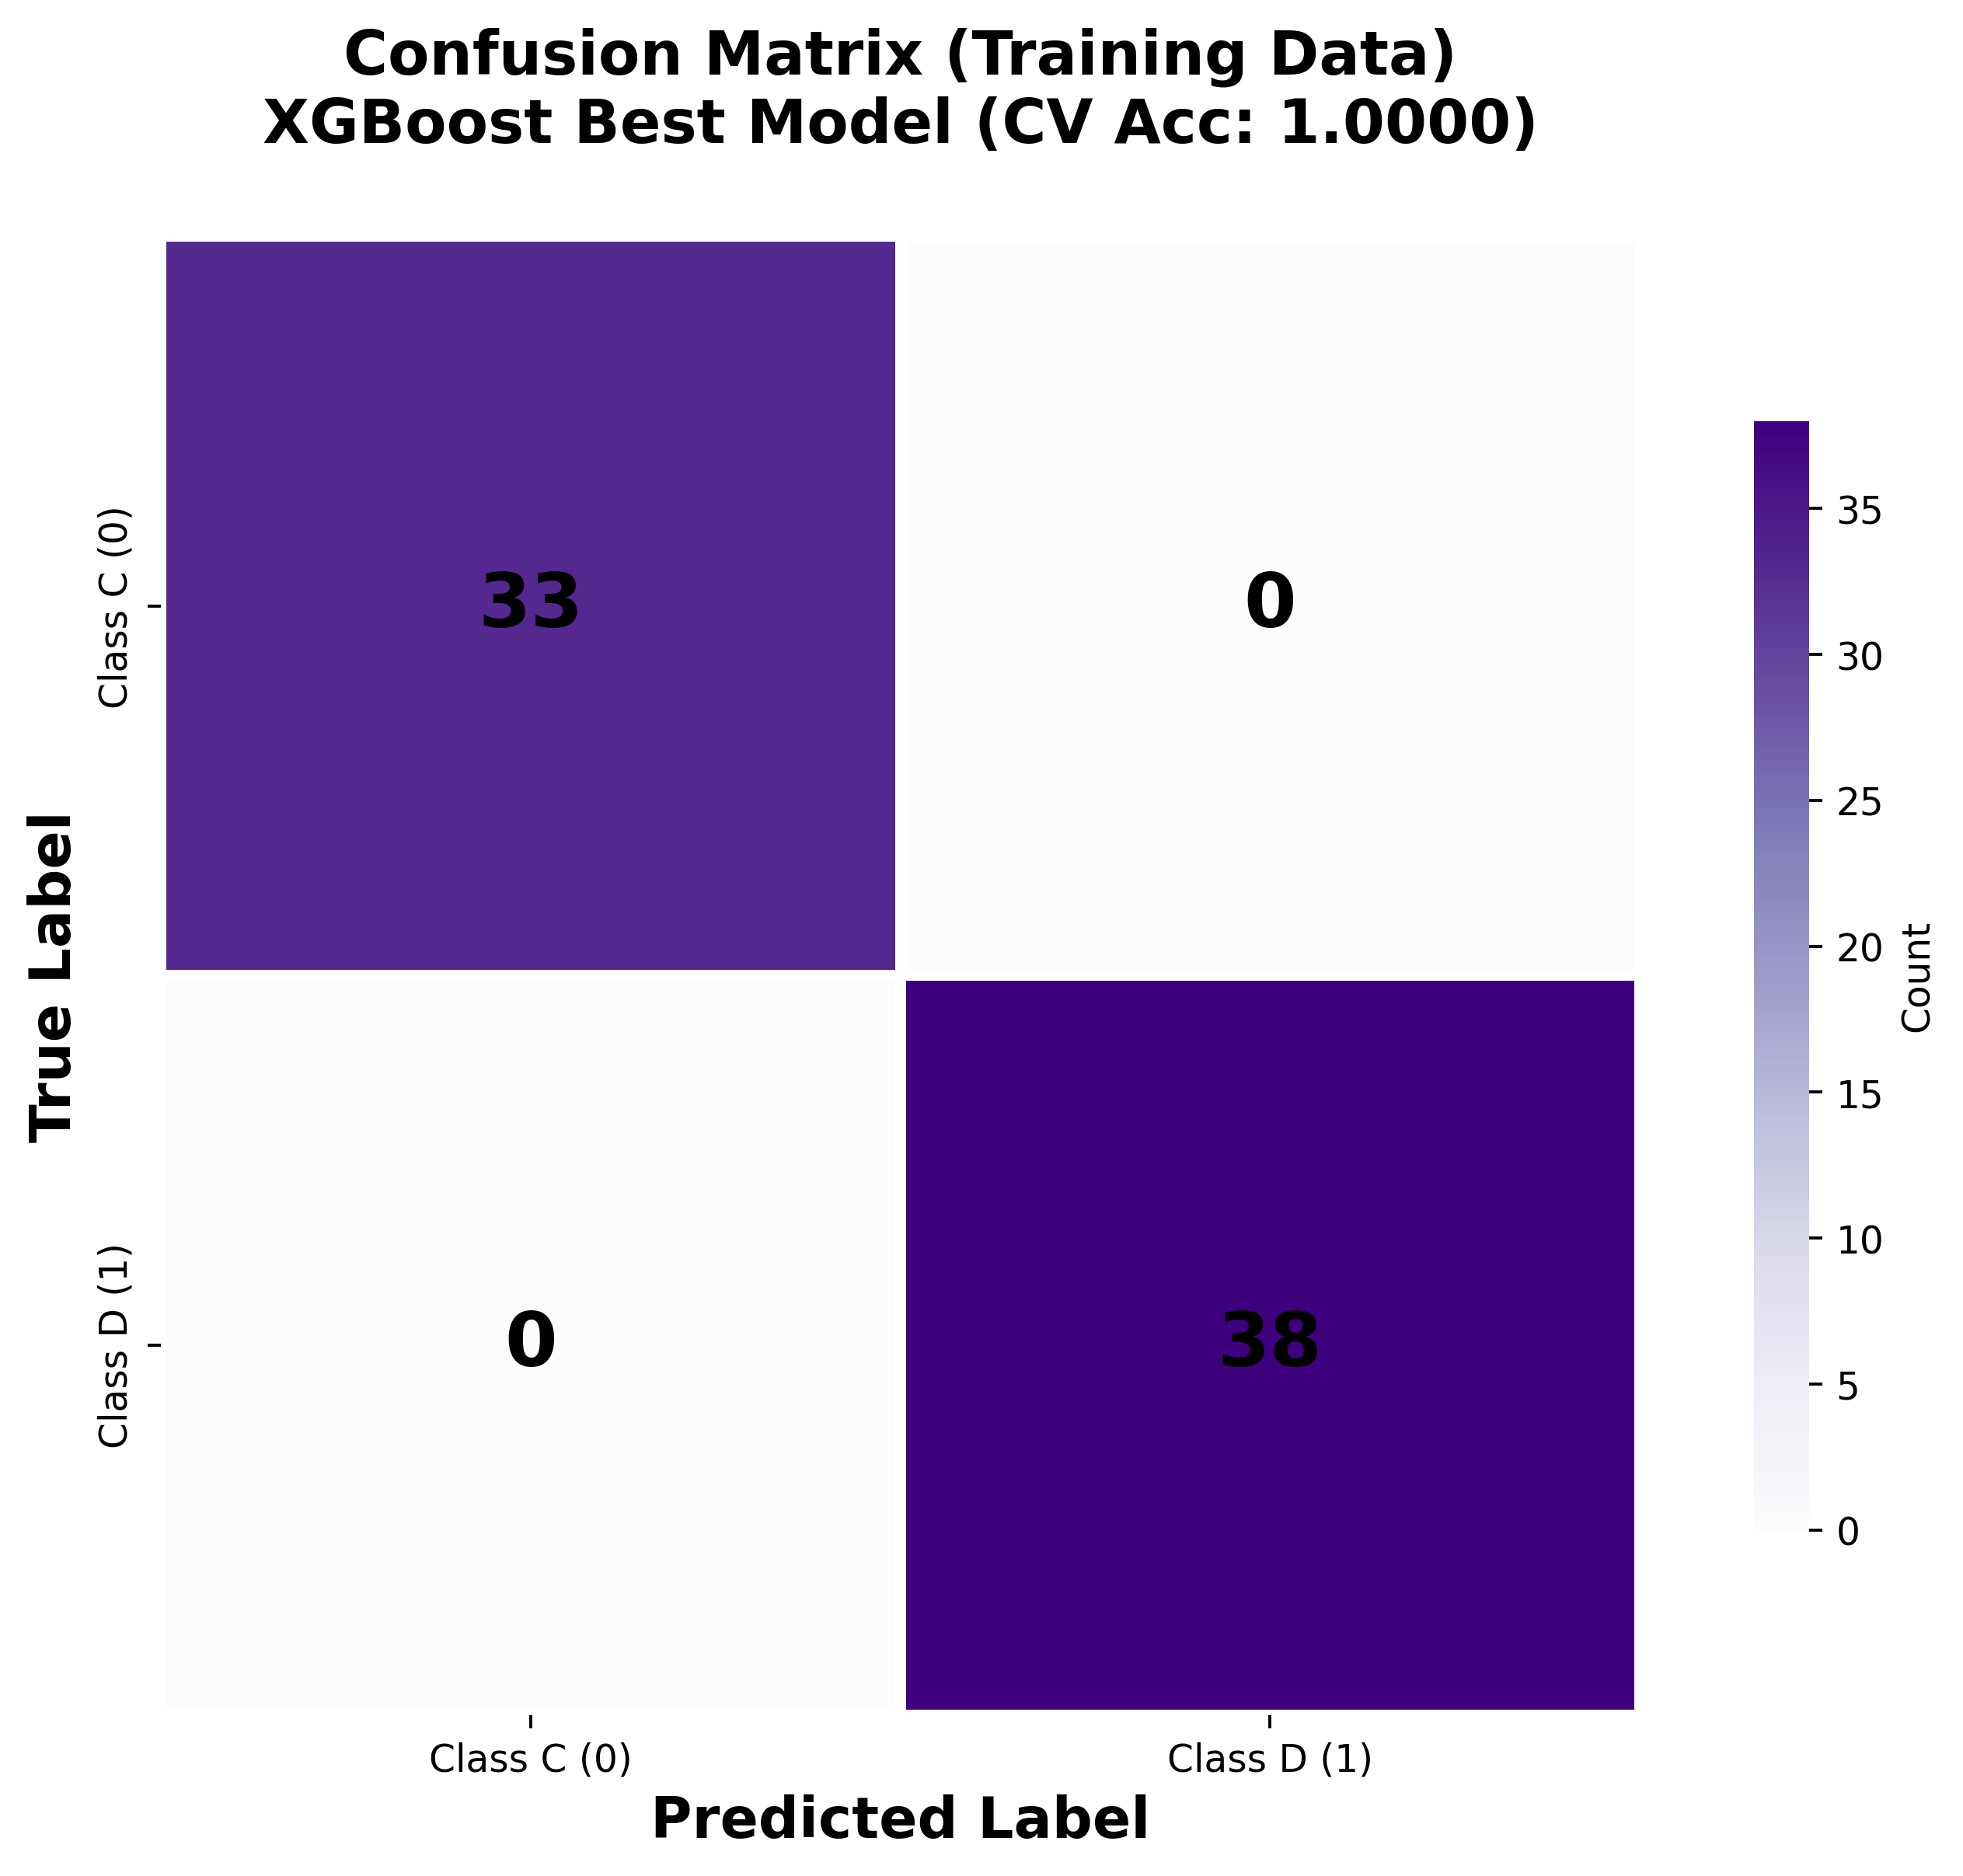

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260606_172020.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 1.0000
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [ ]:



# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")


Calculating SHAP values...
SHAP shape: (71, 49)
X shape   : (71, 49)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_2430/347671843.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


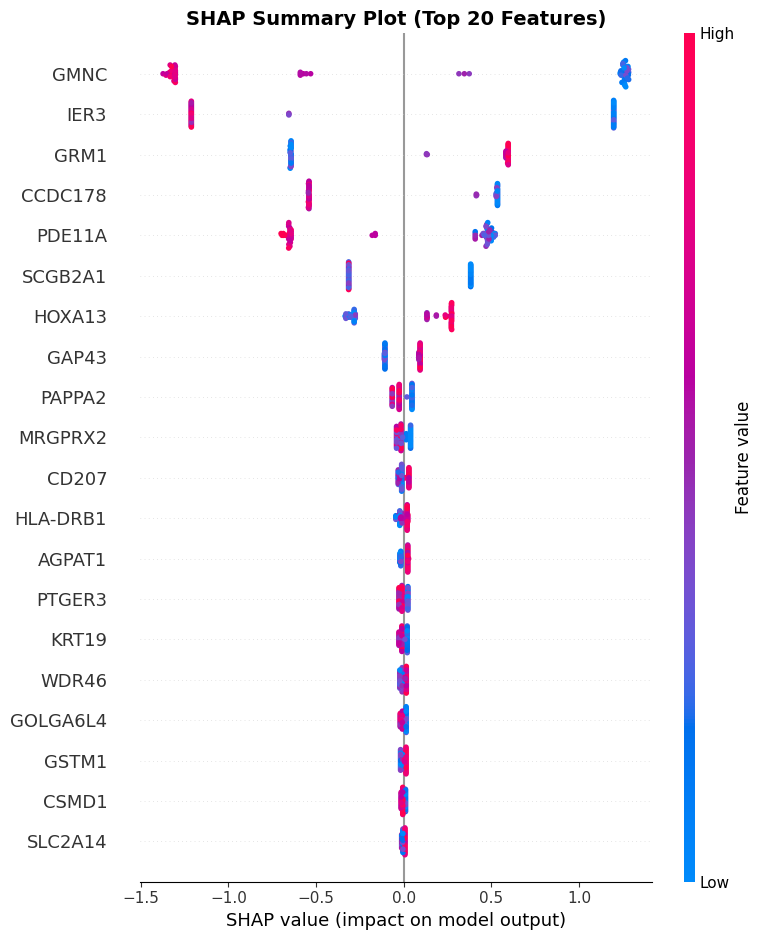

✅ Beeswarm saved


/tmp/ipykernel_2430/347671843.py:64: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


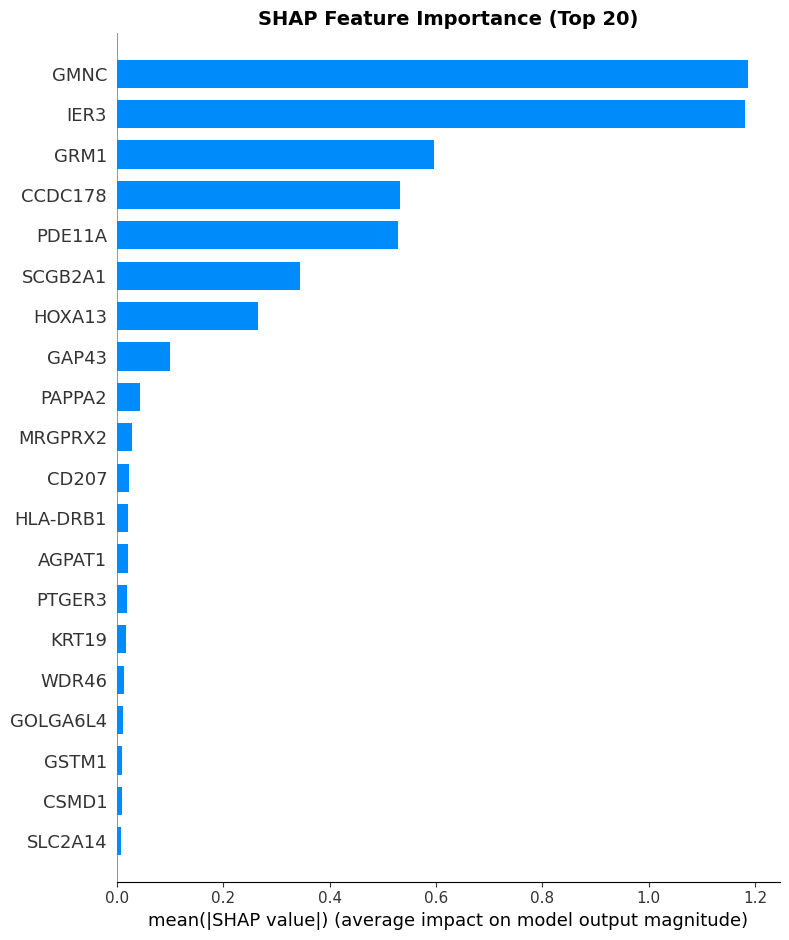

✅ Bar plot saved


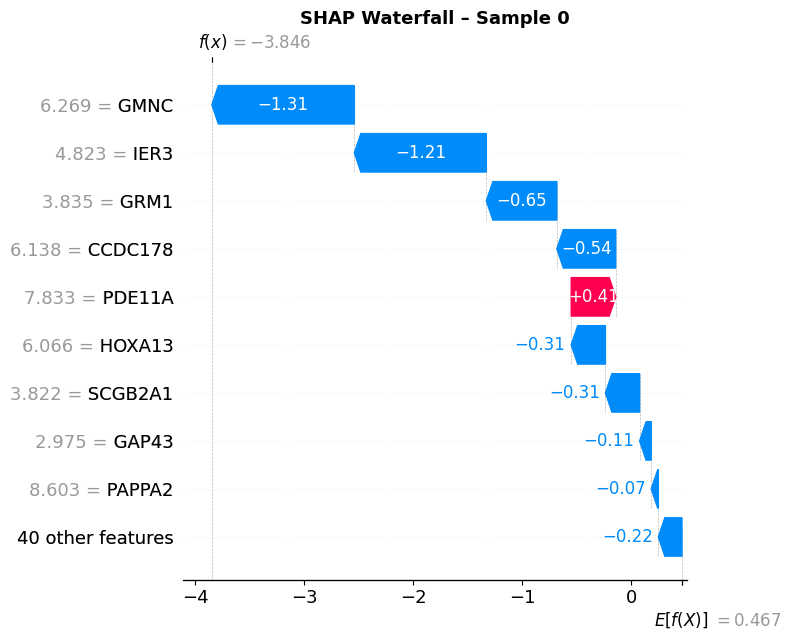

✅ Waterfall saved
✅ Importance CSV saved

Top 10 SHAP Features:
Feature  Mean_Abs_SHAP
   GMNC       1.187456
   IER3       1.181069
   GRM1       0.596907
CCDC178       0.532227
 PDE11A       0.529225
SCGB2A1       0.344585
 HOXA13       0.265888
  GAP43       0.099184
 PAPPA2       0.043932
MRGPRX2       0.028320


In [ ]:
# ==========================
# SHAP ANALYSIS - LIGHTGBM
# ==========================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os

print("\nCalculating SHAP values...")

feature_names = list(X.columns)
X_array = X.values

# --------------------------------------------------
# TreeExplainer (recommended for LightGBM)
# --------------------------------------------------
explainer = shap.TreeExplainer(best_model)

shap_values_raw = explainer.shap_values(X)

# --------------------------------------------------
# Handle binary classification output
# --------------------------------------------------
if isinstance(shap_values_raw, list):

    shap_values = shap_values_raw[1]

    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

else:

    shap_values = shap_values_raw

    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[0]
    else:
        base_val = explainer.expected_value

print("SHAP shape:", np.array(shap_values).shape)
print("X shape   :", X_array.shape)
# ── 9a. Beeswarm Summary ────────────────────────────────────────────────────
plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Beeswarm saved")

# ── 9b. Bar Plot ─────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    plot_type='bar',
    show=False, max_display=20
)
plt.title('SHAP Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_bar_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Bar plot saved")

# ── 9c. Waterfall (sample 0) — guaranteed 1D inputs ─────────────────────────
shap_exp = shap.Explanation(
    values        = shap_values[0],       # 1D (n_features,)
    base_values   = base_val,             # scalar float
    data          = X_array[0],           # 1D (n_features,)
    feature_names = feature_names
)

plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{plot_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall saved")

# ── 9d. Importance CSV ───────────────────────────────────────────────────────
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{plot_timestamp}.csv', index=False)
print(f"✅ Importance CSV saved")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

In [11]:
import pandas as pd

In [12]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [13]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [14]:
data = merged.T

In [15]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y_val = y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X_val= X
import pickle
import joblib
best_model = joblib.load('/content/lightgbm_best_model.pkl')


NameError: name 'model' is not defined

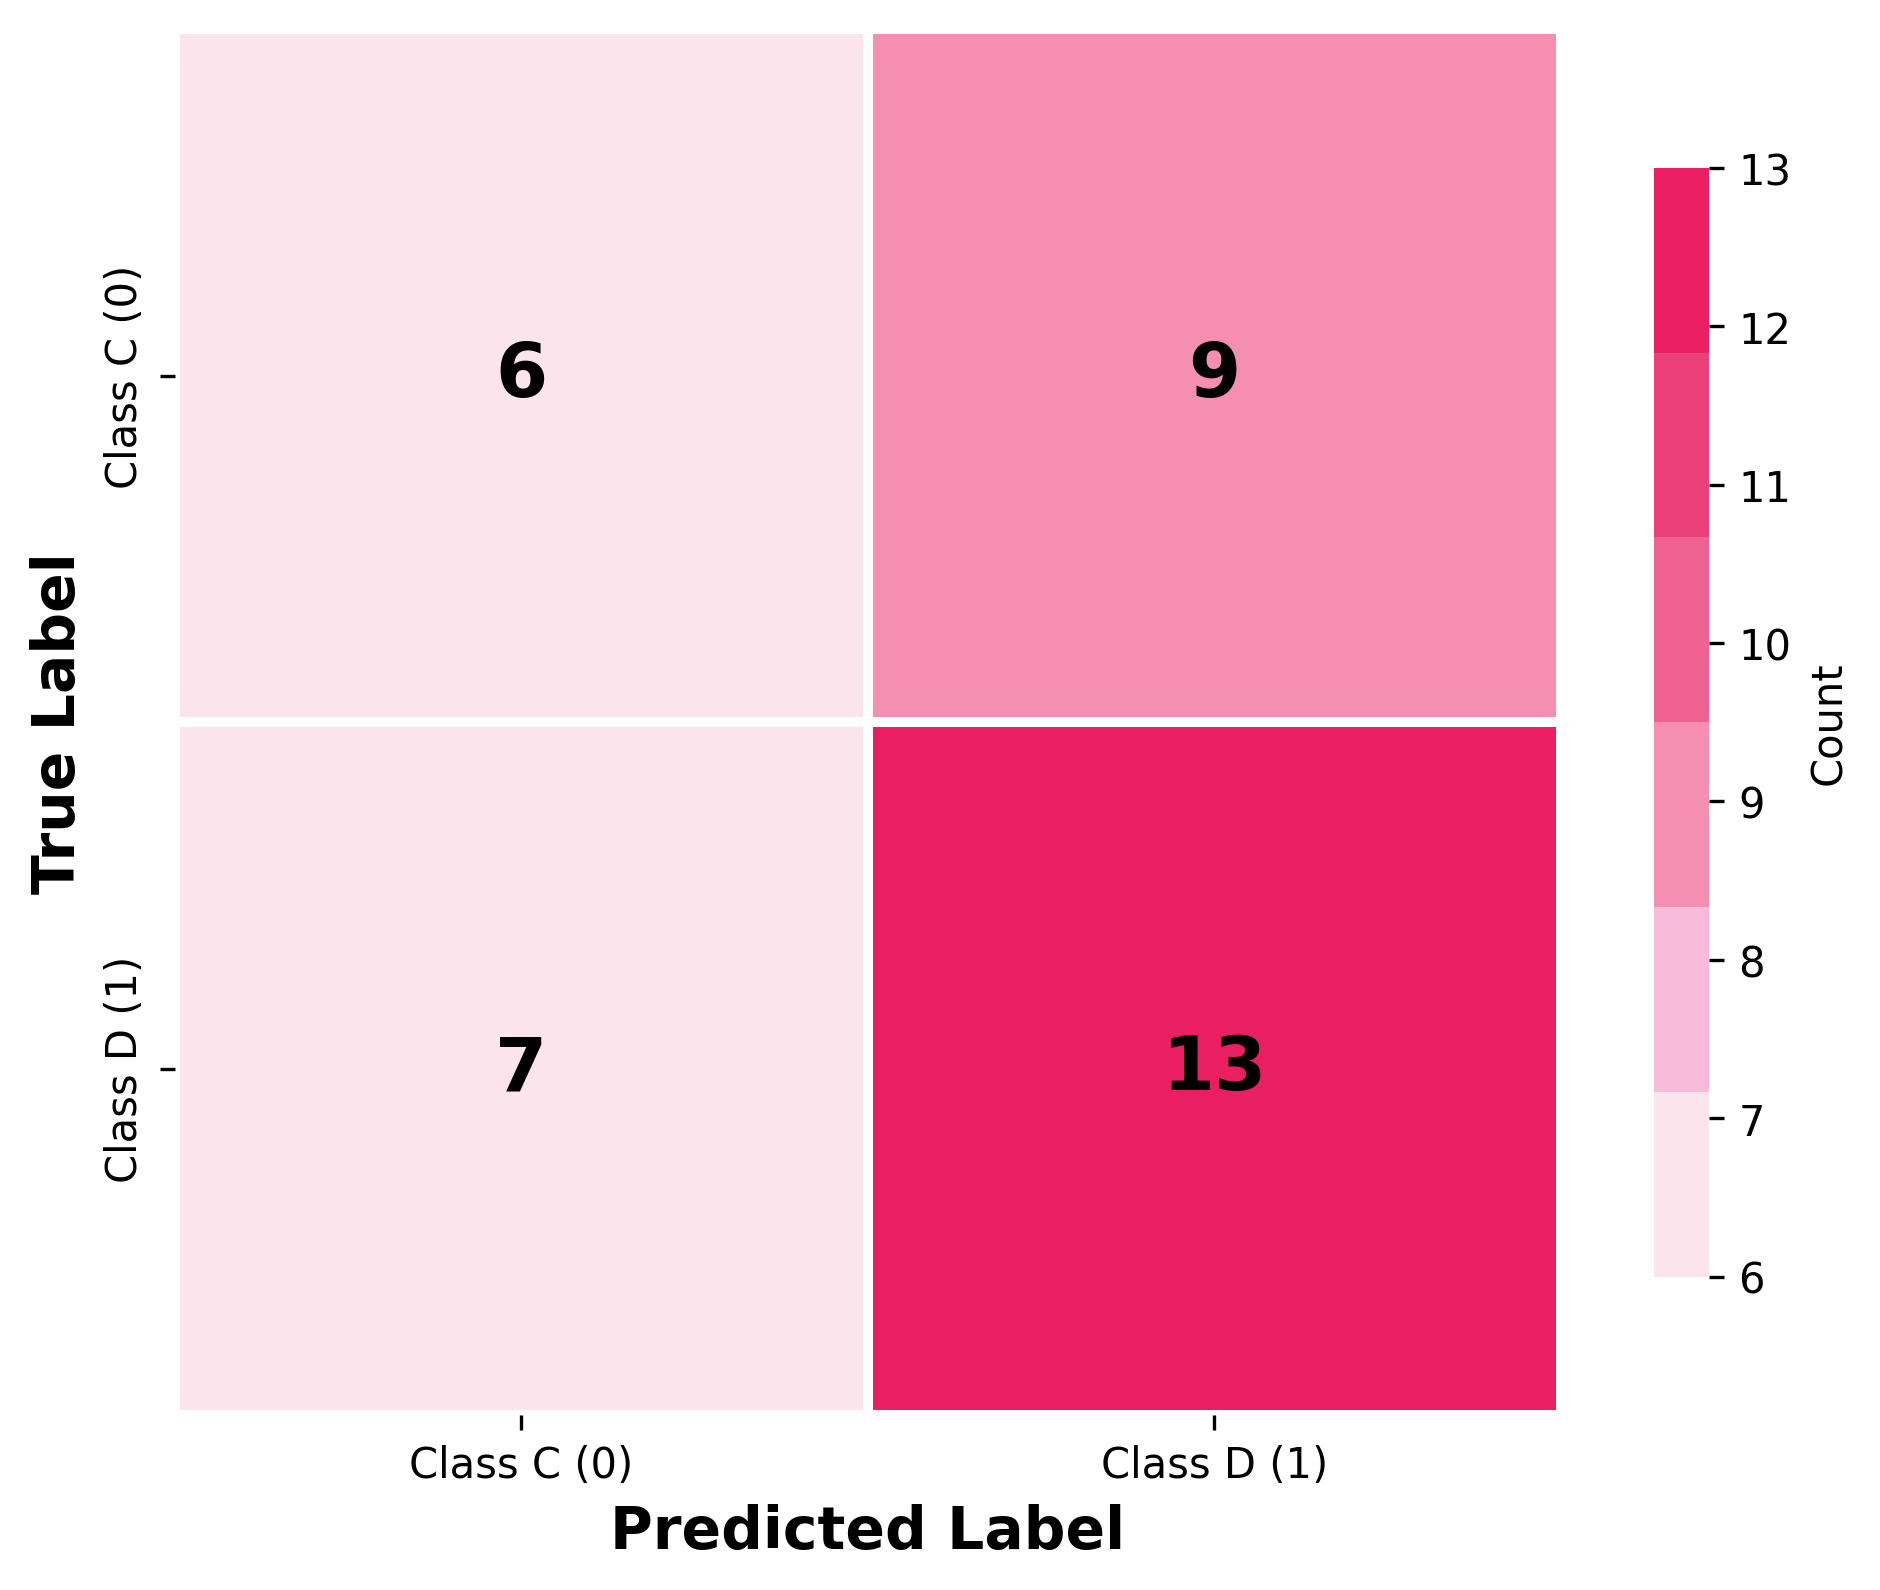

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel: {type(model).__name__}',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_{timestamp}.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [17]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime


# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.5429
ROC-AUC              : 0.5017
AUCPRC               : 0.6038
Avg Precision        : 0.6038
F1 Score             : 0.6190
F1 Macro             : 0.5238
F1 Weighted          : 0.5374
Precision            : 0.5909
Recall               : 0.6500
MCC                  : 0.0512

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0     0.4615    0.4000    0.4286        15
         1.0     0.5909    0.6500    0.6190        20

    accuracy                         0.5429        35
   macro avg     0.5262    0.5250    0.5238        35
weighted avg     0.5355    0.5429    0.5374        35


✅ Metrics saved as 'validation_metrics_20260624_0527.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [18]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


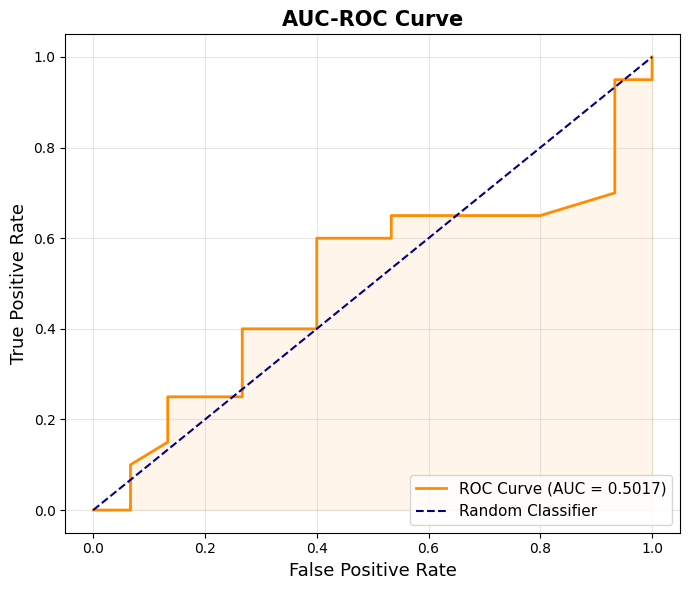

✅ AUC-ROC curve saved as 'aucroc_curve.png'


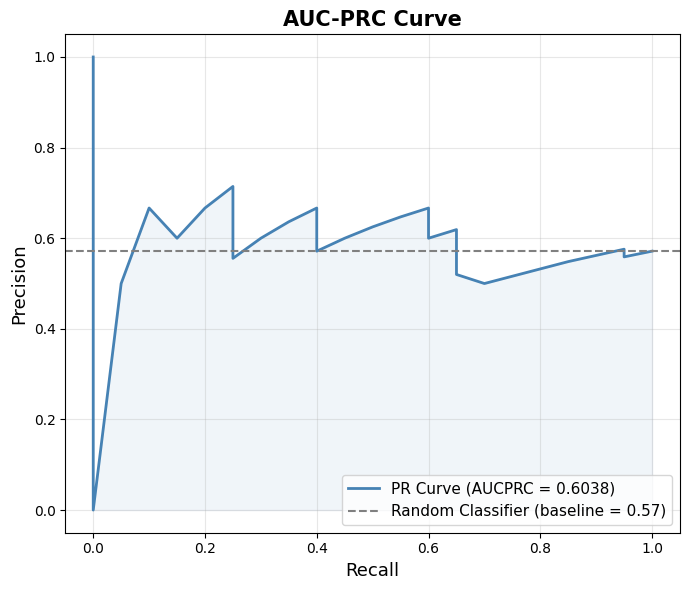

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [19]:

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

